In [1]:
%cd ../
%load_ext autoreload
%autoreload 2

/Users/matthaei/Documents/code/python/bachelor-project


In [2]:
MIGRATE_DATABASE = False

In [3]:
from src.measurements.measurement_service import MeasurementService
from src.weather_stations.weather_station_service import WeatherStationService
from src.wind_turbines.wind_turbines_service import WindTurbinesService
from src.calculation.calculation_service import CalculationService
from src.model.variant.bilstm_model import BiLSTMModel
from src.prediction.prediction_service import PredictionService
from src.database.database_service import DatabaseService
from src.model.model_service import ModelService
from omegaconf import DictConfig, OmegaConf
from hydra import compose, initialize_config_dir
import os
from datetime import datetime
import numpy as np

In [4]:
# Initialize Hydra configuration
config_dir = os.path.abspath("./conf")

# Initialize Hydra with the config directory
with initialize_config_dir(config_dir=config_dir, version_base=None):
    cfg = compose(config_name="config")

In [5]:
database_service = DatabaseService(cfg)

if MIGRATE_DATABASE:
    database_service.create_tables()

In [6]:
weather_station_service = WeatherStationService(cfg, database_service)
weather_stations_df = weather_station_service.load_from_database()

2025-09-18 12:43:33.920 | INFO     | src.weather_stations.weather_station_data_provider:load_from_database:236 - Loaded 32 weather stations from database


In [7]:
measurement_service = MeasurementService(cfg, database_service, weather_stations_df)

In [8]:
model_service = ModelService(cfg, database_service, measurement_service)

In [9]:
lstm = BiLSTMModel()

In [10]:
lstm.load('models/good_lstm/')

In [11]:
model_service.attach_model(lstm)

## Get Predictions


In [12]:
prediction_service = PredictionService(cfg, database_service, measurement_service, model_service)

In [13]:
measurements_df = prediction_service.predict_measurements()

2025-09-18 12:43:34.136 | INFO     | src.measurements.measurement_service:load_all_recent_measurements_from_database:130 - Loading all recent measurements from database
2025-09-18 12:43:34.556 | INFO     | src.measurements.measurement_data_provider:load_measurements_from_database:246 - Loaded chunk of 2304 rows (total so far: 2304)
2025-09-18 12:43:34.653 | INFO     | src.measurements.measurement_data_provider:load_measurements_from_database:255 - Loaded 2304 measurements from database
2025-09-18 12:43:34.654 | INFO     | src.measurements.measurement_service:load_all_recent_measurements_from_database:132 - Loaded 2304 recent measurements from database
2025-09-18 12:43:35.214 | INFO     | src.prediction.prediction_data_provider:save_predictions_to_database:56 - Upserted 200 predictions to database
2025-09-18 12:43:35.390 | INFO     | src.prediction.prediction_data_provider:save_predictions_to_database:56 - Upserted 200 predictions to database
2025-09-18 12:43:35.562 | INFO     | src.pre

In [14]:
measurements_df

,station_id,record_date,u,v,is_prediction
0,96,2025-09-17 02:10:00,3.288924,1.197071,False
72,164,2025-09-17 02:10:00,5.121000,0.902971,False
144,303,2025-09-17 02:10:00,3.758770,1.368081,False
216,427,2025-09-17 02:10:00,3.852740,1.402283,False
288,433,2025-09-17 02:10:00,5.022520,0.885606,False
...,...,...,...,...,...
2015,6106,2025-09-18 02:00:00,-0.582283,-0.725219,True
2087,6253,2025-09-18 02:00:00,-0.601356,-0.745715,True
2159,7351,2025-09-18 02:00:00,-0.593879,-0.737621,True
2231,7389,2025-09-18 02:00:00,-0.515602,-0.654613,True


In [15]:
na_count = measurements_df.isna().sum()
na_count

station_id       0
record_date      0
u                0
v                0
is_prediction    0
dtype: int64

In [16]:
single_station_df = measurements_df[measurements_df["station_id"] == 96]

single_station_df

,station_id,record_date,u,v,is_prediction
0,96,2025-09-17 02:10:00,3.288924,1.197071,False
1,96,2025-09-17 02:20:00,3.382893,1.231273,False
2,96,2025-09-17 02:30:00,3.031089,1.750000,False
3,96,2025-09-17 02:40:00,3.476863,1.265475,False
4,96,2025-09-17 02:50:00,3.288924,1.197071,False
...,...,...,...,...,...
67,96,2025-09-18 01:20:00,-0.544990,-0.680064,True
68,96,2025-09-18 01:30:00,-0.544960,-0.682090,True
69,96,2025-09-18 01:40:00,-0.539772,-0.680412,True
70,96,2025-09-18 01:50:00,-0.539833,-0.680301,True


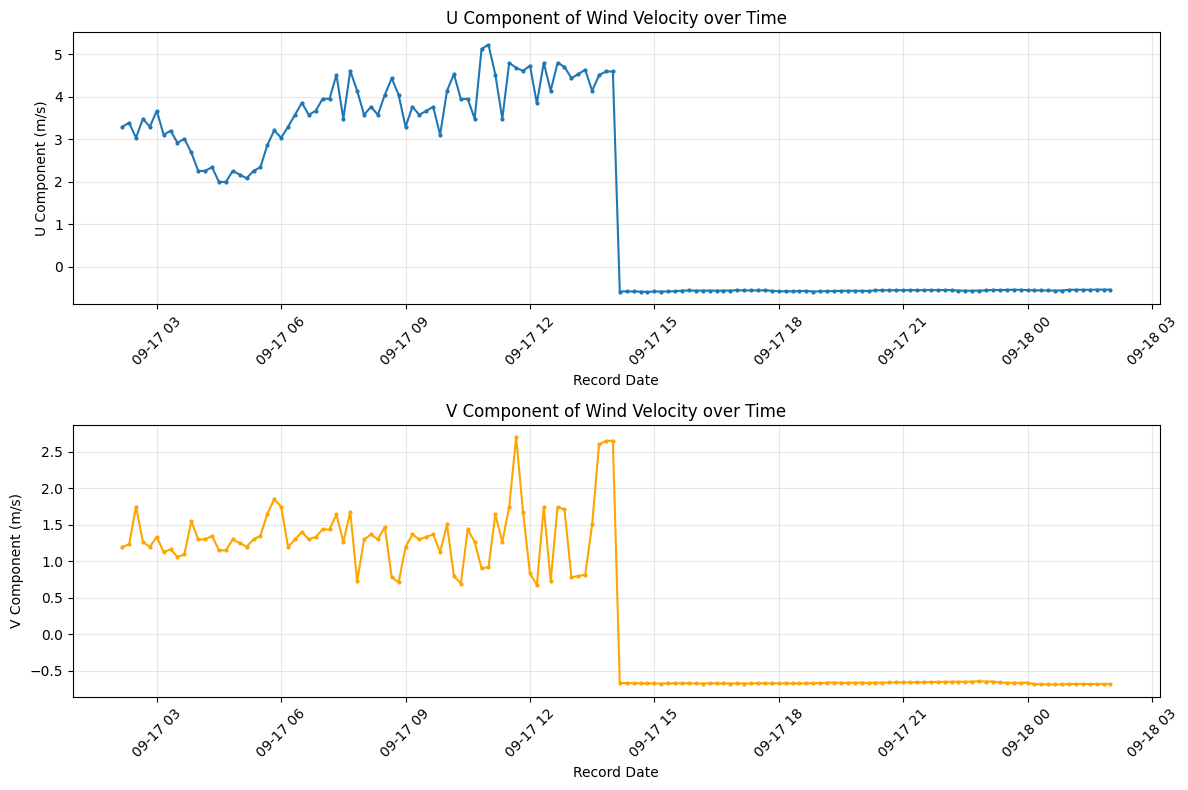

In [17]:
import matplotlib.pyplot as plt

# Create subplots for u and v components
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot u component
ax1.plot(single_station_df['record_date'], single_station_df['u'], marker='o', markersize=2)
ax1.set_title('U Component of Wind Velocity over Time')
ax1.set_xlabel('Record Date')
ax1.set_ylabel('U Component (m/s)')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot v component
ax2.plot(single_station_df['record_date'], single_station_df['v'], marker='o', markersize=2, color='orange')
ax2.set_title('V Component of Wind Velocity over Time')
ax2.set_xlabel('Record Date')
ax2.set_ylabel('V Component (m/s)')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [18]:
measurements_df.sort_values(by="record_date", inplace=True, ascending=True)

measurements_df

,station_id,record_date,u,v,is_prediction
0,96,2025-09-17 02:10:00,3.288924,1.197071,False
2232,7393,2025-09-17 02:10:00,4.134648,1.504889,False
2160,7389,2025-09-17 02:10:00,5.168309,1.881111,False
2088,7351,2025-09-17 02:10:00,4.134648,1.504889,False
2016,6253,2025-09-17 02:10:00,3.983717,2.300000,False
...,...,...,...,...,...
143,164,2025-09-18 02:00:00,-0.598304,-0.742385,True
71,96,2025-09-18 02:00:00,-0.541298,-0.681442,True
2231,7389,2025-09-18 02:00:00,-0.515602,-0.654613,True
1079,3093,2025-09-18 02:00:00,-0.596840,-0.740936,True


In [19]:
measurements_df.dropna(inplace=True)
measurements_df


,station_id,record_date,u,v,is_prediction
0,96,2025-09-17 02:10:00,3.288924,1.197071,False
2232,7393,2025-09-17 02:10:00,4.134648,1.504889,False
2160,7389,2025-09-17 02:10:00,5.168309,1.881111,False
2088,7351,2025-09-17 02:10:00,4.134648,1.504889,False
2016,6253,2025-09-17 02:10:00,3.983717,2.300000,False
...,...,...,...,...,...
143,164,2025-09-18 02:00:00,-0.598304,-0.742385,True
71,96,2025-09-18 02:00:00,-0.541298,-0.681442,True
2231,7389,2025-09-18 02:00:00,-0.515602,-0.654613,True
1079,3093,2025-09-18 02:00:00,-0.596840,-0.740936,True


In [20]:
test_df = measurements_df.copy().sort_values(by="u", inplace=False, ascending=False)
test_df


,station_id,record_date,u,v,is_prediction
759,1869,2025-09-17 08:40:00,9.749597,1.719117e+00,False
1567,5109,2025-09-17 11:20:00,9.700000,1.781861e-15,False
1576,5109,2025-09-17 12:50:00,9.300000,1.708382e-15,False
1560,5109,2025-09-17 10:10:00,9.200000,1.690013e-15,False
773,1869,2025-09-17 11:00:00,9.158712,1.614928e+00,False
...,...,...,...,...,...
940,3015,2025-09-17 14:50:00,-0.652870,-7.329019e-01,True
436,1001,2025-09-17 14:50:00,-0.653724,-7.338746e-01,True
76,164,2025-09-17 14:50:00,-0.653999,-7.343019e-01,True
2020,6253,2025-09-17 14:50:00,-0.657264,-7.377389e-01,True


## Extrapolate u and v to all wind turbines for all intervals

In [21]:
wind_turbines_service = WindTurbinesService(cfg, database_service)

In [22]:
all_wind_turbines_df = wind_turbines_service.load_from_database()

2025-09-18 12:43:38.064 | INFO     | src.wind_turbines.wind_turbines_data_provider:load_from_database:144 - Loaded 4798 wind turbines from database


In [23]:
all_wind_turbines_df.head()

,final_decommission_date,gross_power,hub_height,last_update_date,latitude,longitude,manufacturer,net_nominal_power,rotor_diameter,technology,type_designation,unit_mastr_number
0,None,2000.0,105.0,2023-12-14 09:19:12.317844,52.602453,13.789959,1660.0,2000.0,90.0,691,V90-2MW,SEE985818635128
1,None,2530.0,120.0,2025-06-12 09:17:52.784566,51.892620,13.490910,1597.0,2530.0,120.0,691,GE 2.5-120,SEE954065333897
2,None,3450.0,140.0,2024-10-09 14:40:42.676992,52.361379,14.367995,1660.0,3450.0,112.0,691,V112 3.3/3.45 MW,SEE948721850590
3,None,2000.0,100.0,2024-06-07 15:18:36.556635,52.339744,13.261313,1660.0,2000.0,80.0,691,V-80,SEE992411107808
4,None,2530.0,120.0,2025-02-04 14:52:11.195789,51.890410,13.484510,1597.0,2530.0,120.0,691,GE 2.5-120,SEE933244215582


In [24]:
calculation_service = CalculationService(cfg, database_service, measurement_service, all_wind_turbines_df, weather_stations_df)

In [25]:
extrapolated_measurements_df = calculation_service.extrapolate_u_and_v_to_all_wind_turbines(measurements_df)

In [26]:
extrapolated_measurements_df

,unit_mastr_number,latitude,longitude,manufacturer,type_designation,hub_height,record_date,u,v,is_prediction
0,SEE985818635128,52.602453,13.789959,1660.0,V90-2MW,105.0,2025-09-17 02:10:00,4.638278,1.585898,False
1,SEE954065333897,51.892620,13.490910,1597.0,GE 2.5-120,120.0,2025-09-17 02:10:00,3.894497,1.610695,False
2,SEE948721850590,52.361379,14.367995,1660.0,V112 3.3/3.45 MW,140.0,2025-09-17 02:10:00,4.154286,1.232789,False
3,SEE992411107808,52.339744,13.261313,1660.0,V-80,100.0,2025-09-17 02:10:00,4.720431,1.558009,False
4,SEE933244215582,51.890410,13.484510,1597.0,GE 2.5-120,120.0,2025-09-17 02:10:00,3.894739,1.615635,False
...,...,...,...,...,...,...,...,...,...,...
690907,SEE918240568382,53.086816,14.172692,1660.0,V162-7.2,169.0,2025-09-18 02:00:00,-0.589496,-0.733026,True
690908,SEE995556497261,53.084103,14.170340,1660.0,V162-7.2,169.0,2025-09-18 02:00:00,-0.589542,-0.733075,True
690909,SEE961783448895,53.085005,14.178594,1660.0,V162-7.2,169.0,2025-09-18 02:00:00,-0.589334,-0.732852,True
690910,SEE912922789966,53.105845,14.104210,1001682.0,Nordex N163/6.X,164.0,2025-09-18 02:00:00,-0.591700,-0.735371,True


In [27]:
single_turbine_df = extrapolated_measurements_df[extrapolated_measurements_df["unit_mastr_number"] == "SEE933612141345"]

single_turbine_df

,unit_mastr_number,latitude,longitude,manufacturer,type_designation,hub_height,record_date,u,v,is_prediction
99,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-17 02:10:00,4.109545,1.772443,False
4897,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-17 02:20:00,3.844114,1.924774,False
9695,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-17 02:30:00,3.613814,1.883216,False
14493,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-17 02:40:00,3.681721,1.732447,False
19291,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-17 02:50:00,3.706729,1.628555,False
...,...,...,...,...,...,...,...,...,...,...
667021,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-18 01:20:00,-0.589759,-0.727736,True
671819,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-18 01:30:00,-0.589703,-0.729803,True
676617,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-18 01:40:00,-0.584712,-0.728378,True
681415,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-18 01:50:00,-0.584688,-0.728237,True


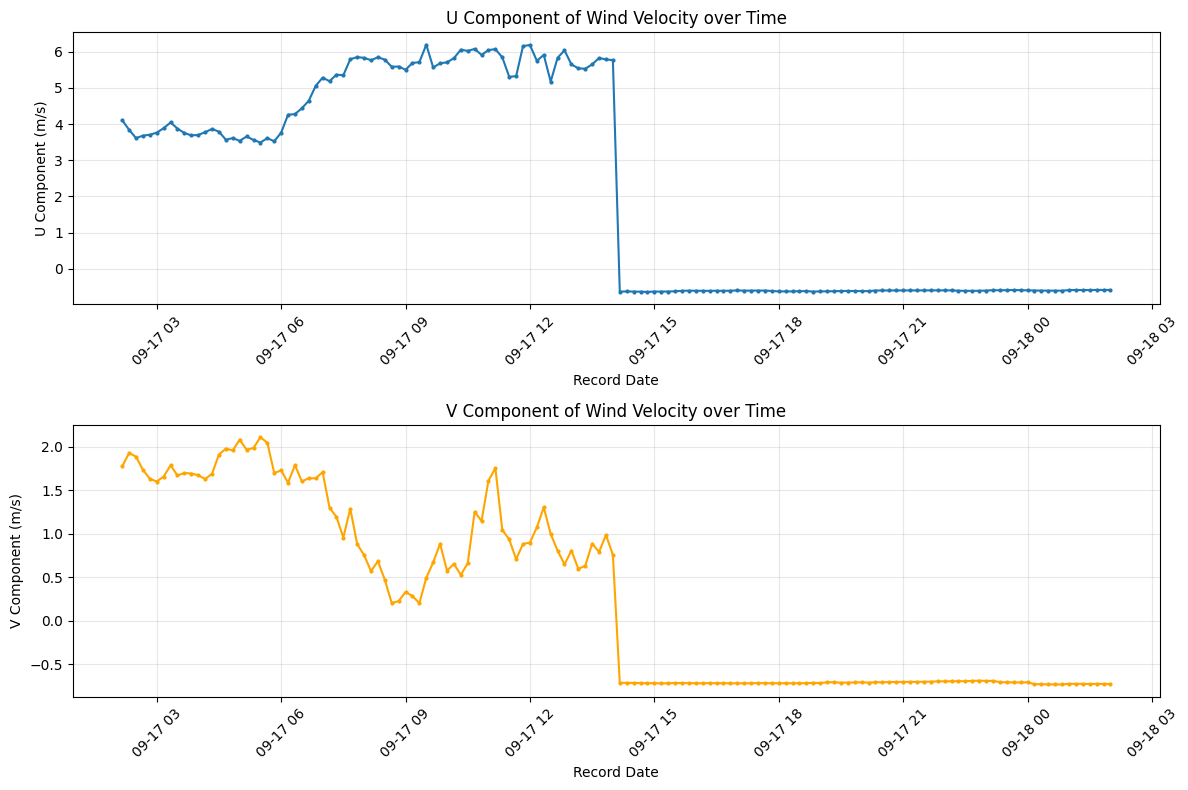

In [28]:
import matplotlib.pyplot as plt

# Create subplots for u and v components
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot u component
ax1.plot(single_turbine_df['record_date'], single_turbine_df['u'], marker='o', markersize=2)
ax1.set_title('U Component of Wind Velocity over Time')
ax1.set_xlabel('Record Date')
ax1.set_ylabel('U Component (m/s)')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot v component
ax2.plot(single_turbine_df['record_date'], single_turbine_df['v'], marker='o', markersize=2, color='orange')
ax2.set_title('V Component of Wind Velocity over Time')
ax2.set_xlabel('Record Date')
ax2.set_ylabel('V Component (m/s)')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [29]:
extended_extrapolated_measurements_df = calculation_service.extrapolate_to_hub_height(extrapolated_measurements_df)

In [30]:
extended_extrapolated_measurements_df

,unit_mastr_number,latitude,longitude,manufacturer,type_designation,hub_height,record_date,u,v,is_prediction,wind_speed,hub_height_wind_speed
0,SEE985818635128,52.602453,13.789959,1660.0,V90-2MW,105.0,2025-09-17 02:10:00,4.638278,1.585898,False,4.901908,6.812894
1,SEE954065333897,51.892620,13.490910,1597.0,GE 2.5-120,120.0,2025-09-17 02:10:00,3.894497,1.610695,False,4.214433,5.967941
2,SEE948721850590,52.361379,14.367995,1660.0,V112 3.3/3.45 MW,140.0,2025-09-17 02:10:00,4.154286,1.232789,False,4.333343,6.270195
3,SEE992411107808,52.339744,13.261313,1660.0,V-80,100.0,2025-09-17 02:10:00,4.720431,1.558009,False,4.970901,6.861754
4,SEE933244215582,51.890410,13.484510,1597.0,GE 2.5-120,120.0,2025-09-17 02:10:00,3.894739,1.615635,False,4.216547,5.970934
...,...,...,...,...,...,...,...,...,...,...,...,...
690907,SEE918240568382,53.086816,14.172692,1660.0,V162-7.2,169.0,2025-09-18 02:00:00,-0.589496,-0.733026,True,0.940655,1.397445
690908,SEE995556497261,53.084103,14.170340,1660.0,V162-7.2,169.0,2025-09-18 02:00:00,-0.589542,-0.733075,True,0.940722,1.397544
690909,SEE961783448895,53.085005,14.178594,1660.0,V162-7.2,169.0,2025-09-18 02:00:00,-0.589334,-0.732852,True,0.940418,1.397093
690910,SEE912922789966,53.105845,14.104210,1001682.0,Nordex N163/6.X,164.0,2025-09-18 02:00:00,-0.591700,-0.735371,True,0.943864,1.396329


In [31]:
# max hub_height_wind_speed
extended_extrapolated_measurements_df["hub_height_wind_speed"].max()


np.float64(14.617668336864526)

## Calculate power production

In [ ]:
wind_power_production_df = calculation_service.calculate_power_production(extended_extrapolated_measurements_df)

<unknown>:156: SyntaxWarning: invalid escape sequence '\s'
<unknown>:156: SyntaxWarning: invalid escape sequence '\s'
2025-09-18 12:47:57.148 | INFO     | src.calculation.power_curves_data_provider:get_all_turbine_id_for_mastr_number:10 - Loaded 4614 turbine ids
2025-09-18 12:47:57.818 | INFO     | src.calculation.power_curves_data_provider:load_from_database:109 - Loaded 894 power curves from database
2025-09-18 12:48:02.229 | INFO     | src.calculation.wind_calculation_data_provider:save_calculations_to_database:381 - Upserted calculations chunk 0-7500 of 690912
2025-09-18 12:48:03.636 | INFO     | src.calculation.wind_calculation_data_provider:save_calculations_to_database:381 - Upserted calculations chunk 7500-15000 of 690912
2025-09-18 12:48:04.893 | INFO     | src.calculation.wind_calculation_data_provider:save_calculations_to_database:381 - Upserted calculations chunk 15000-22500 of 690912
2025-09-18 12:48:06.160 | INFO     | src.calculation.wind_calculation_data_provider:save_c

In [33]:
wind_power_production_df

,unit_mastr_number,latitude,longitude,manufacturer,type_designation,hub_height,record_date,u,v,is_prediction,wind_speed,hub_height_wind_speed,pred_power_production
0,SEE985818635128,52.602453,13.789959,1660.0,V90-2MW,105.0,2025-09-17 02:10:00,4.638278,1.585898,False,4.901908,6.812894,580.0
1,SEE954065333897,51.892620,13.490910,1597.0,GE 2.5-120,120.0,2025-09-17 02:10:00,3.894497,1.610695,False,4.214433,5.967941,704.0
2,SEE948721850590,52.361379,14.367995,1660.0,V112 3.3/3.45 MW,140.0,2025-09-17 02:10:00,4.154286,1.232789,False,4.333343,6.270195,555.0
3,SEE992411107808,52.339744,13.261313,1660.0,V-80,100.0,2025-09-17 02:10:00,4.720431,1.558009,False,4.970901,6.861754,1850.0
4,SEE933244215582,51.890410,13.484510,1597.0,GE 2.5-120,120.0,2025-09-17 02:10:00,3.894739,1.615635,False,4.216547,5.970934,704.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
690907,SEE918240568382,53.086816,14.172692,1660.0,V162-7.2,169.0,2025-09-18 02:00:00,-0.589496,-0.733026,True,0.940655,1.397445,0.0
690908,SEE995556497261,53.084103,14.170340,1660.0,V162-7.2,169.0,2025-09-18 02:00:00,-0.589542,-0.733075,True,0.940722,1.397544,0.0
690909,SEE961783448895,53.085005,14.178594,1660.0,V162-7.2,169.0,2025-09-18 02:00:00,-0.589334,-0.732852,True,0.940418,1.397093,0.0
690910,SEE912922789966,53.105845,14.104210,1001682.0,Nordex N163/6.X,164.0,2025-09-18 02:00:00,-0.591700,-0.735371,True,0.943864,1.396329,NaN


In [34]:
wind_power_production_df.columns


Index(['unit_mastr_number', 'latitude', 'longitude', 'manufacturer',
       'type_designation', 'hub_height', 'record_date', 'u', 'v',
       'is_prediction', 'wind_speed', 'hub_height_wind_speed',
       'pred_power_production'],
      dtype='object')